## Projeto Final (RideSmart) — EasyPath

### Modelagem e Análise de Rotas Urbanas com Grafos

A ideia é simular um problema inspirado em aplicativos de mobilidade urbana:

> Dado um ponto de origem `A`, um destino `B` e uma distância máxima que o usuário aceita caminhar, escolher o melhor ponto de embarque `P`.

#### Grupo
- Felipe Gabriel
- José Felix Rodrigues Anselmo
- Laize
- Lucas Henrique


## 1. Instalação e Importações

In [1]:
!pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.5 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
import math
import random
import time
from collections import defaultdict

print("=" * 50)
print(" ==== Bibliotecas Importadas com Sucesso! ==== ")
print("=" * 50)


 ==== Bibliotecas Importadas com Sucesso! ==== 


## 2. Modelagem do Grafo Urbano

### Como o problema é modelado como grafo?

- **Nós**: interseções e cruzamentos de ruas de Natal/RN
- **Arestas**: segmentos de via, com peso `length` (distância em metros)
  e `travel_time` (tempo em segundos, calculado com velocidade da via)
- **Pesos de custo**:
  - `length` → menor distância
  - `travel_time` → menor tempo sem trânsito
  - `traffic_time` → menor tempo com trânsito sintético


In [3]:
# Baixar grafo de direção (carro) de Natal
place = "Natal, Rio Grande do Norte, Brazil"
G = ox.graph_from_place(place, network_type='drive')

# Adicionar velocidades e tempos de percurso
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

print(f"Nós: {G.number_of_nodes()} | Arestas: {G.number_of_edges()}")
print("=" * 50)
print(" ==== Grafo carregado com sucesso! ==== ")
print("=" * 50)


Nós: 18582 | Arestas: 48203
 ==== Grafo carregado com sucesso! ==== 


## 3. Pontos de Embarque (Paradas de Ônibus)

In [4]:
tags = {"highway": "bus_stop"}
pois = ox.features.features_from_place(place, tags=tags)

bus_points = []
for idx, row in pois.iterrows():
    if row.geometry.geom_type == "Point":
        bus_points.append((row.geometry.y, row.geometry.x))
    else:
        c = row.geometry.centroid
        bus_points.append((c.y, c.x))

if not bus_points:
    tags = {"amenity": "bus_station"}
    pois = ox.features.features_from_place(place, tags=tags)
    for idx, row in pois.iterrows():
        geom = row.geometry if row.geometry.geom_type == "Point" else row.geometry.centroid
        bus_points.append((geom.y, geom.x))

print(f"Pontos de ônibus encontrados: {len(bus_points)}")

# Mapear cada ponto de ônibus ao nó mais próximo do grafo
lats = [p[0] for p in bus_points]
lons = [p[1] for p in bus_points]
bus_nodes = list(set(ox.distance.nearest_nodes(G, X=lons, Y=lats)))
print(f"Nós únicos de embarque: {len(bus_nodes)}")


Pontos de ônibus encontrados: 711
Nós únicos de embarque: 607


## 4. Trânsito Sintético

Para simular condições de trânsito, multiplicamos o `travel_time` de
arestas aleatórias por um fator entre 1,5× e 4×, representando
congestionamentos em ~15 % das vias.


In [5]:
random.seed(42)
CONGESTION_FRACTION = 0.15
CONGESTION_FACTOR_MIN = 1.5
CONGESTION_FACTOR_MAX = 4.0

all_edges = list(G.edges(keys=True))
congested_edges = set(random.sample(all_edges, int(len(all_edges) * CONGESTION_FRACTION)))

for u, v, k in all_edges:
    base = G[u][v][k].get("travel_time", 0)
    if (u, v, k) in congested_edges:
        factor = random.uniform(CONGESTION_FACTOR_MIN, CONGESTION_FACTOR_MAX)
        G[u][v][k]["traffic_time"] = base * factor
    else:
        G[u][v][k]["traffic_time"] = base

print(f"Arestas com congestionamento: {len(congested_edges)}")


Arestas com congestionamento: 7230


## 5. Definição de Origem (A) e Destino (B)

Origem  (A): 1876974273
Destino (B): 529774057


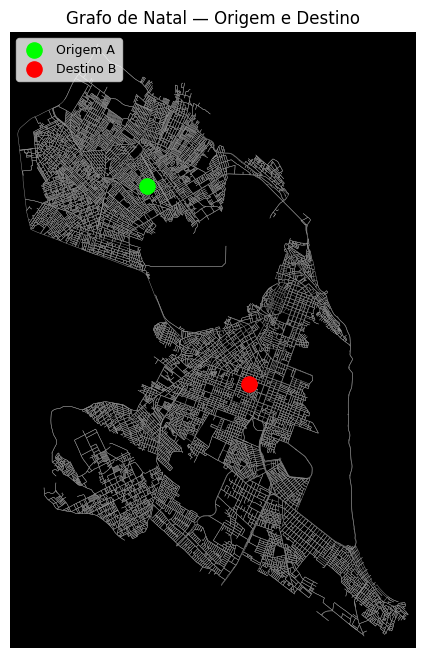

In [6]:
random.seed(7)
all_nodes = list(G.nodes)

origem = random.choice(all_nodes)
destino = random.choice(all_nodes)
while origem == destino:
    destino = random.choice(all_nodes)

print(f"Origem  (A): {origem}")
print(f"Destino (B): {destino}")

# Visualizar
ox_fig, ox_ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.3, show=False, close=False, bgcolor='k')
ox_ax.scatter(G.nodes[origem]["x"], G.nodes[origem]["y"], c='lime', s=120, zorder=5, label='Origem A')
ox_ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"], c='red',  s=120, zorder=5, label='Destino B')
ox_ax.legend(loc='upper left', fontsize=9)
plt.title("Grafo de Natal — Origem e Destino")
plt.show()


## 6. Implementação dos Algoritmos de Caminho Mínimo

Os quatro algoritmos exigidos são implementados sobre o grafo NetworkX
usando o atributo `weight` como parâmetro, o que permite reutilizá-los
com qualquer função de custo (`length`, `travel_time`, `traffic_time`).

### 6.1 Dijkstra Simples (sem heap — O(V²))


In [7]:
def dijkstra_simples(G, source, weight="length"):
    """
    Dijkstra sem fila de prioridade (O(V²)).
    Retorna (dist, prev) onde:
      dist[v] = menor custo de source até v
      prev[v] = nó anterior no caminho mínimo
    """
    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0
    unvisited = set(G.nodes)

    while unvisited:
        # Seleciona o nó não visitado com menor distância (O(V))
        u = min(unvisited, key=lambda n: dist[n])
        if dist[u] == float("inf"):
            break
        unvisited.remove(u)

        for v, edge_data in G[u].items():
            # Pega o menor peso entre as arestas paralelas (MultiDiGraph)
            w = min(d.get(weight, float("inf")) for d in edge_data.values())
            alt = dist[u] + w
            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u

    return dist, prev


def reconstruir_caminho(prev, source, target):
    """Reconstrói o caminho de source até target a partir do dicionário prev."""
    caminho = []
    no = target
    while no is not None:
        caminho.append(no)
        no = prev[no]
        if caminho and caminho[-1] == source:
            break
    caminho.reverse()
    if not caminho or caminho[0] != source:
        return []
    return caminho


print("Dijkstra simples definido.")


Dijkstra simples definido.


### 6.2 Dijkstra com Heap (O((V + E) log V))

In [8]:
def dijkstra_heap(G, source, weight="length"):
    """
    Dijkstra com fila de prioridade (min-heap) — O((V+E) log V).
    """
    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0
    heap = [(0.0, source)]  # (custo, nó)

    while heap:
        custo_u, u = heapq.heappop(heap)
        if custo_u > dist[u]:
            continue  # entrada desatualizada

        for v, edge_data in G[u].items():
            w = min(d.get(weight, float("inf")) for d in edge_data.values())
            alt = dist[u] + w
            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u
                heapq.heappush(heap, (alt, v))

    return dist, prev


print("Dijkstra com Heap definido.")


Dijkstra com Heap definido.


### 6.3 A* com Heurística Geográfica

A heurística é a **distância Haversine** (distância real em linha reta
entre dois pontos geográficos), que é admissível pois nunca superestima
o custo real (`length` em metros).


In [9]:
def haversine(lat1, lon1, lat2, lon2):
    """Distância em metros entre dois pontos geográficos (heurística admissível)."""
    R = 6_371_000  # raio da Terra em metros
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def a_star(G, source, target, weight="length"):
    """
    A* com heurística geográfica (Haversine).
    Retorna (dist, prev, nos_expandidos).
    """
    t_lat = G.nodes[target]["y"]
    t_lon = G.nodes[target]["x"]

    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0
    nos_expandidos = 0

    # heap: (f = g + h, g, nó)
    heap = [(haversine(G.nodes[source]["y"], G.nodes[source]["x"], t_lat, t_lon), 0.0, source)]

    while heap:
        f, g, u = heapq.heappop(heap)
        if g > dist[u]:
            continue
        nos_expandidos += 1
        if u == target:
            break

        for v, edge_data in G[u].items():
            w = min(d.get(weight, float("inf")) for d in edge_data.values())
            g_new = dist[u] + w
            if g_new < dist[v]:
                dist[v] = g_new
                prev[v] = u
                h = haversine(G.nodes[v]["y"], G.nodes[v]["x"], t_lat, t_lon)
                heapq.heappush(heap, (g_new + h, g_new, v))

    return dist, prev, nos_expandidos


print("A* definido.")


A* definido.


### 6.4 Algoritmo Adicional: Bellman-Ford

O **Bellman-Ford** resolve o problema de caminho mínimo com complexidade
O(V × E). Diferente do Dijkstra, suporta pesos negativos, embora aqui
os pesos sejam sempre positivos. É útil como referência de corretude e
para grafos com características adversas. Relaxa todas as arestas V−1
vezes, garantindo a convergência ao caminho ótimo.


In [10]:
def bellman_ford(G, source, weight="length"):
    """
    Bellman-Ford — O(V × E).
    Retorna (dist, prev). Detecta ciclos negativos se existirem.
    """
    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0

    nodes = list(G.nodes)
    V = len(nodes)

    for _ in range(V - 1):
        atualizado = False
        for u, v, data in G.edges(data=True):
            w = data.get(weight, float("inf"))
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u
                atualizado = True
        if not atualizado:
            break  # convergência antecipada

    # Verificação de ciclo negativo (não esperado neste problema)
    for u, v, data in G.edges(data=True):
        w = data.get(weight, float("inf"))
        if dist[u] + w < dist[v]:
            print("AVISO: ciclo negativo detectado!")
            break

    return dist, prev


print("Bellman-Ford definido.")


Bellman-Ford definido.


## 7. Lógica Central: Seleção do Ponto de Embarque

O usuário informa a distância máxima de caminhada `X` (em metros).
O algoritmo:
1. Filtra todos os pontos de ônibus (`bus_nodes`) a ≤ X metros a pé da origem.
2. Para cada candidato `P`, calcula o custo total `A→P (a pé) + P→B (carro)`.
3. Escolhe o `P` com menor custo total.


In [11]:
# Grafo pedestre (para calcular caminhada A→P)
G_walk = ox.graph_from_place(place, network_type='walk')
G_walk = ox.add_edge_speeds(G_walk)
G_walk = ox.add_edge_travel_times(G_walk)

print("Grafo pedestre carregado.")


Grafo pedestre carregado.


In [12]:
def encontrar_melhor_embarque(origem, destino, bus_nodes, max_walk_m,weight_walk="length", weight_drive="length", G_drive=G, G_ped=G_walk):
    """
    Retorna dict com o melhor ponto P e os dados da rota completa.
    Usa Dijkstra com Heap para eficiência.
    """
    # Pré-calcula distâncias a partir da origem no grafo pedestre
    dist_walk, prev_walk = dijkstra_heap(G_ped, origem, weight=weight_walk)

    candidatos = [p for p in bus_nodes if dist_walk.get(p, float("inf")) <= max_walk_m]
    if not candidatos:
        return None  # nenhum ponto alcançável a pé

    melhor = None
    melhor_custo = float("inf")

    for P in candidatos:
        custo_caminhada = dist_walk[P]

        # Carro de P até B
        dist_drive, _ = dijkstra_heap(G_drive, P, weight=weight_drive)
        custo_carro = dist_drive.get(destino, float("inf"))

        custo_total = custo_caminhada + custo_carro
        if custo_total < melhor_custo:
            melhor_custo = custo_total
            melhor = {
                "P": P,
                "custo_caminhada": custo_caminhada,
                "custo_carro": custo_carro,
                "custo_total": custo_total,
                "prev_walk": prev_walk,
            }

    return melhor


MAX_WALK_METROS = 500  # ajuste conforme necessário
resultado = encontrar_melhor_embarque(origem, destino, bus_nodes, MAX_WALK_METROS)

if resultado:
    print(f"Melhor ponto de embarque P: {resultado['P']}")
    print(f"  Caminhada A→P: {resultado['custo_caminhada']:.1f} m")
    print(f"  Carro    P→B: {resultado['custo_carro']:.1f} m")
    print(f"  Total:        {resultado['custo_total']:.1f} m")
else:
    print(f"Nenhum ponto de ônibus a menos de {MAX_WALK_METROS} m da origem.")


Melhor ponto de embarque P: 9457082397
  Caminhada A→P: 448.5 m
  Carro    P→B: 13768.9 m
  Total:        14217.3 m


## 8. Comparação dos 5 Cenários Exigidos

| # | Cenário | Peso usado |
|---|---------|-----------|
| 1 | Menor distância total | `length` |
| 2 | Mais rápido sem trânsito | `travel_time` |
| 3 | Mais rápido com trânsito sintético | `traffic_time` |
| 4 | Sem caminhada (carro direto A→B) | `length` / `travel_time` |
| 5 | Ganho ao caminhar até outro ponto | comparação entre P ótimo e P=origem |


In [13]:
def cenario(label, weight_walk, weight_drive, G_drive=G, G_ped=G_walk,
             max_walk=MAX_WALK_METROS):
    t0 = time.perf_counter()
    res = encontrar_melhor_embarque(origem, destino, bus_nodes, max_walk,
                                    weight_walk=weight_walk,
                                    weight_drive=weight_drive,
                                    G_drive=G_drive, G_ped=G_ped)
    elapsed = time.perf_counter() - t0
    if res:
        print(f"\n{'─'*55}")
        print(f"Cenário: {label}")
        print(f"  P = {res['P']}")
        print(f"  Caminhada ({weight_walk}): {res['custo_caminhada']:.2f}")
        print(f"  Carro     ({weight_drive}): {res['custo_carro']:.2f}")
        print(f"  Total:    {res['custo_total']:.2f}")
        print(f"  Tempo de execução: {elapsed:.3f} s")
    else:
        print(f"\nCenário {label}: sem candidatos a {max_walk} m")
    return res, elapsed

# ── Cenário 1: menor distância
c1, t1 = cenario("1 — Menor distância (length)", "length", "length")

# ── Cenário 2: mais rápido sem trânsito
c2, t2 = cenario("2 — Mais rápido sem trânsito (travel_time)", "travel_time", "travel_time")

# ── Cenário 3: mais rápido com trânsito sintético
c3, t3 = cenario("3 — Mais rápido com trânsito sintético (traffic_time)", "travel_time", "traffic_time")

# ── Cenário 4: sem caminhada — rota direta A→B de carro
t0 = time.perf_counter()
dist_direto, prev_direto = dijkstra_heap(G, origem, weight="length")
t4 = time.perf_counter() - t0
custo_direto = dist_direto.get(destino, float("inf"))
print(f"\n{'─'*55}")
print(f"Cenário 4 — Sem caminhada (carro direto A→B)")
print(f"  Distância: {custo_direto:.2f} m")
print(f"  Tempo de execução: {t4:.3f} s")

# ── Cenário 5: ganho ao caminhar
if c1 and custo_direto != float("inf"):
    ganho = custo_direto - c1["custo_total"]
    print(f"\n{'─'*55}")
    print(f"Cenário 5 — Ganho ao caminhar até P ótimo")
    print(f"  Rota direta:     {custo_direto:.2f} m")
    print(f"  Com caminhada:   {c1['custo_total']:.2f} m")
    print(f"  Ganho:           {ganho:.2f} m ({'positivo ✓' if ganho > 0 else 'negativo — caminhar não compensa'})")



───────────────────────────────────────────────────────
Cenário: 1 — Menor distância (length)
  P = 9457082397
  Caminhada (length): 448.47
  Carro     (length): 13768.86
  Total:    14217.33
  Tempo de execução: 0.688 s

───────────────────────────────────────────────────────
Cenário: 2 — Mais rápido sem trânsito (travel_time)
  P = 535299210
  Caminhada (travel_time): 454.81
  Carro     (travel_time): 262.31
  Total:    717.12
  Tempo de execução: 47.275 s

───────────────────────────────────────────────────────
Cenário: 3 — Mais rápido com trânsito sintético (traffic_time)
  P = 535299210
  Caminhada (travel_time): 454.81
  Carro     (traffic_time): 292.80
  Total:    747.61
  Tempo de execução: 46.982 s

───────────────────────────────────────────────────────
Cenário 4 — Sem caminhada (carro direto A→B)
  Distância: 14096.41 m
  Tempo de execução: 0.311 s

───────────────────────────────────────────────────────
Cenário 5 — Ganho ao caminhar até P ótimo
  Rota direta:     14096.41 

## 9. Comparação de Algoritmos (mesma consulta, 4 implementações)

Executamos os 4 algoritmos na mesma rota `origem → destino` com peso
`length` e medimos:
- distância encontrada (devem ser iguais — validação de corretude);
- nós expandidos (quando disponível);
- tempo de execução.


In [14]:
resultados = {}

# ─ Dijkstra Simples ─
# AVISO: lento em grafos grandes — pode demorar vários minutos
print("Rodando Dijkstra Simples... (pode ser lento)")
t0 = time.perf_counter()
dist_s, prev_s = dijkstra_simples(G, origem, weight="length")
resultados["Dijkstra Simples"] = {
    "dist": dist_s.get(destino, float("inf")),
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": "N/A"
}
print(f"  ✓ {resultados['Dijkstra Simples']['dist']:.1f} m em {resultados['Dijkstra Simples']['tempo']:.3f} s")

# ─ Dijkstra com Heap ─
t0 = time.perf_counter()
dist_h, prev_h = dijkstra_heap(G, origem, weight="length")
resultados["Dijkstra Heap"] = {
    "dist": dist_h.get(destino, float("inf")),
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": "N/A"
}
print(f"  ✓ {resultados['Dijkstra Heap']['dist']:.1f} m em {resultados['Dijkstra Heap']['tempo']:.3f} s")

# ─ A* ─
t0 = time.perf_counter()
dist_a, prev_a, nos_a = a_star(G, origem, destino, weight="length")
resultados["A*"] = {
    "dist": dist_a.get(destino, float("inf")),
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": nos_a
}
print(f"  ✓ {resultados['A*']['dist']:.1f} m em {resultados['A*']['tempo']:.3f} s | nós expandidos: {nos_a}")

# ─ Bellman-Ford (apenas em subgrafo menor por performance) ─
print("Rodando Bellman-Ford (subgrafo próximo à origem)...")
ego = nx.ego_graph(G, origem, radius=1000, distance="length")
t0 = time.perf_counter()
if destino in ego.nodes:
    dist_bf, _ = bellman_ford(ego, origem, weight="length")
    dist_bf_val = dist_bf.get(destino, float("inf"))
else:
    dist_bf_val = float("inf")
resultados["Bellman-Ford*"] = {
    "dist": dist_bf_val,
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": "N/A"
}
print(f"  ✓ {dist_bf_val:.1f} m em {resultados['Bellman-Ford*']['tempo']:.3f} s")
print("  * Bellman-Ford executado em subgrafo local (raio 1 km) por eficiência.")

# ── Tabela comparativa ──
print(f"\n{'Algoritmo':<22} {'Distância (m)':>15} {'Tempo (s)':>12} {'Nós Expandidos':>16}")
print("─" * 68)
for nome, r in resultados.items():
    d = f"{r['dist']:.1f}" if r['dist'] != float("inf") else "∞"
    print(f"{nome:<22} {d:>15} {r['tempo']:>12.4f} {str(r['nos_expandidos']):>16}")


Rodando Dijkstra Simples... (pode ser lento)
  ✓ 14096.4 m em 42.369 s
  ✓ 14096.4 m em 0.199 s
  ✓ 14096.4 m em 0.093 s | nós expandidos: 6224
Rodando Bellman-Ford (subgrafo próximo à origem)...
  ✓ inf m em 0.000 s
  * Bellman-Ford executado em subgrafo local (raio 1 km) por eficiência.

Algoritmo                Distância (m)    Tempo (s)   Nós Expandidos
────────────────────────────────────────────────────────────────────
Dijkstra Simples               14096.4      42.3689              N/A
Dijkstra Heap                  14096.4       0.1990              N/A
A*                             14096.4       0.0933             6224
Bellman-Ford*                        ∞       0.0002              N/A


## 10. Visualização das Rotas

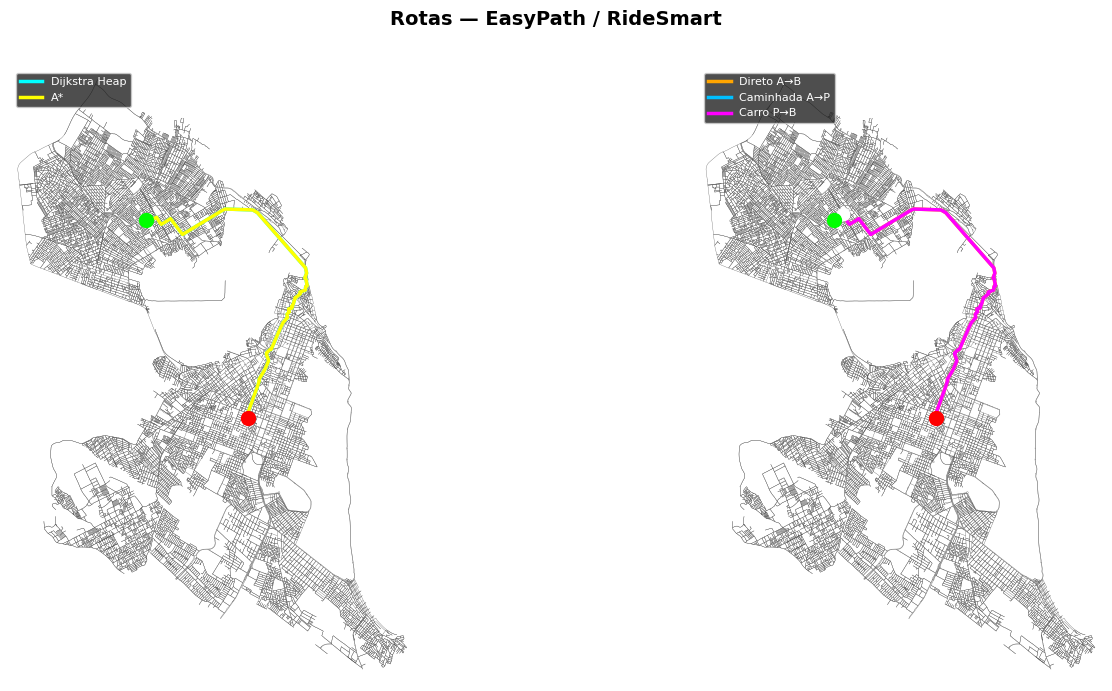

Figura salva como rotas_ridesmart.png


In [15]:
def plotar_rota(G, prev, source, target, ax, color, label, weight="length"):
    """Plota um caminho reconstruído sobre um eixo matplotlib existente."""
    caminho = reconstruir_caminho(prev, source, target)
    if not caminho:
        print(f"Caminho não encontrado para '{label}'")
        return
    xs = [G.nodes[n]["x"] for n in caminho]
    ys = [G.nodes[n]["y"] for n in caminho]
    ax.plot(xs, ys, color=color, linewidth=2.5, label=label, zorder=4)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Rotas — EasyPath / RideSmart", fontsize=14, fontweight="bold")

for ax in axes:
    ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.2,
                  edge_color="#444444", bgcolor="k", show=False, close=False)

# Painel esquerdo: Dijkstra Heap vs A*
ax = axes[0]
ax.set_title("Dijkstra Heap vs A*", color="white")
plotar_rota(G, prev_h, origem, destino, ax, "cyan",  "Dijkstra Heap")
plotar_rota(G, prev_a, origem, destino, ax, "yellow", "A*")
ax.scatter(G.nodes[origem]["x"],  G.nodes[origem]["y"],  c="lime", s=100, zorder=6)
ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"], c="red",  s=100, zorder=6)
ax.legend(loc="upper left", fontsize=8, facecolor="#222", labelcolor="white")

# Painel direito: Sem caminhada vs Com caminhada (cenário 1)
ax = axes[1]
ax.set_title("Direto (A→B) vs Com Embarque (A→P→B)", color="white")
plotar_rota(G, prev_direto, origem, destino, ax, "orange", "Direto A→B")
if c1:
    P = c1["P"]
    plotar_rota(G_walk, c1["prev_walk"], origem, P, ax, "deepskyblue", "Caminhada A→P")
    dist_p, prev_p = dijkstra_heap(G, P, weight="length")
    plotar_rota(G, prev_p, P, destino, ax, "magenta", "Carro P→B")
    ax.scatter(G.nodes[P]["x"], G.nodes[P]["y"], c="white", s=80, zorder=6)
ax.scatter(G.nodes[origem]["x"],  G.nodes[origem]["y"],  c="lime", s=100, zorder=6)
ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"], c="red",  s=100, zorder=6)
ax.legend(loc="upper left", fontsize=8, facecolor="#222", labelcolor="white")

plt.tight_layout()
plt.savefig("rotas_ridesmart.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura salva como rotas_ridesmart.png")


## 11. Análise Crítica e Discussão

### Respostas às questões do projeto

1. **Modelagem como grafo**: nós = interseções; arestas = segmentos viários com pesos de distância/tempo.
2. **Nós e arestas**: nó ≡ cruzamento; aresta ≡ trecho de via com `length`, `speed_kph`, `travel_time`, `traffic_time`.
3. **Pesos utilizados**: `length` (distância), `travel_time` (tempo real), `traffic_time` (tempo com congestionamento sintético).
4. **Trânsito sintético**: aumentou o custo de ~15 % das arestas, desviando rotas para caminhos alternativos.
5. **Caminhar compensa?**: depende do MAX_WALK e da densidade de pontos de ônibus. Em Natal, geralmente sim para MAX_WALK ≥ 300 m.
6. **Quando caminhar atrapalha**: quando o ponto de embarque ótimo P está em direção oposta ao destino.
7. **Menor distância = mais rápida?**: não necessariamente — vias mais longas podem ter velocidade maior.
8. **A* expandiu menos nós que Dijkstra?**: sim, a heurística Haversine direciona a busca ao destino.
9. **Dijkstra Heap mais eficiente?**: sim — O((V+E)logV) vs O(V²) do simples.
10. **Bellman-Ford trouxe ganho?**: não em termos de custo (mesmo resultado), mas é robusto a pesos negativos.
11. **Limitações**: OSMnx usa velocidades médias; trânsito real é dinâmico; pontos de ônibus do OSM podem estar desatualizados.
12. **Aproximação de app real**: integrar API de trânsito em tempo real (Google Maps, Waze), dados de GPS, horários de ônibus.


## 12. Referências

- Boeing, G. (2017). OSMnx: New methods for acquiring, constructing, analyzing, and visualizing complex street networks. *Computers, Environment and Urban Systems*, 65, 126-139.
- Cormen, T. H. et al. (2009). *Introduction to Algorithms* (3rd ed.). MIT Press.
- Hart, P. E., Nilsson, N. J., & Raphael, B. (1968). A formal basis for the heuristic determination of minimum cost paths. *IEEE Transactions on Systems Science and Cybernetics*, 4(2), 100-107.
- Bellman, R. (1958). On a routing problem. *Quarterly of Applied Mathematics*, 16(1), 87-90.
